# **<span style="color: #000000;background-color: rgb(255, 245, 177)">딥러닝2(TRANSFORMER) 사전과제</span>**

### **필수내용**
- RNN의 한계
    - Attention의 등장 배경 및 장점
    - Attention is All You Need
- Self-Attention
    - Query, Key, Value 개념
    - Cross Attention vs. Self-Attention 개념 및 과정
    - Scaled Dpt-Product Attention
- Multi-Head Attention
    - Multi-Head Attention 개념
    - Multi-Head Attention 작동방식
- Transformer 전체 아키텍처
    - 전처리 단계(토큰화 - 임베딩 - Positional Encoding)
    - Encoder와 Decoder

---

### <span style="color: #000000;background-color: #ffdba4">**1. 어텐션 등장**</span>

#### <span style="color: #000000;background-color: #ffc2e5">   **1-(1) RNN의 한계와 어텐션의 등장**</span> 
##### <span style="color: #27baff">   **[RNN의 한계]** <span>
- RNN 
    -   앞뒤 내용이 서로 연관된 데이터에 대해 기억을 통해 이전 단계에서 처리한 정보를 현재 단계의 입력에 함께 활용하는 신경망
    - 구조
        - input, hidden, output layer
        - 이전 시점의 입력에 대해 출력이 나오고 이전 시점의 히든 값은 다음 시점의 히든값으로 전달됨
    - 한계점
        - 장기 의존성 문제 : 데이터가 길어질수록, 데이터의 후반부에서 초반에 위치한 정보가 잘 반영되지 않음 
        - Vanishing gradient : 학습시 이전 값들을 현재 값에 적용할 때 가중치가 곱해지는데 횟수가 늘어나면서 계산 값이 0이 되는 문제
- LSTM
    - RNN의 Vanishing gradient 문제를 해결하고자 등장
    - 중요한 것은 오래 기억, 필요 없는 것은 잊어버리자
    - 구조
        - Input, Forget, Output gate
    - 한계점
        - 계산이 복잡하고 시간이 오래걸림
        - 여전히 긴문장에서 Vanishing Gradient 발생

##### <span style="color: #27baff">   **[Attention의 등장]** <span>
등장 배경 : <U>Seq2Seq의 병목 현상</U>
- 입력 문장이 길어질수록 하나의 벡터에 모든 정보를 담기 어려워져 중요한 정보가 손실되는 문제 발생
- 매번 같은 컨텍스트 벡터 참고 -> 출력 단어마다 필요한 정보를 다르게 반영하기 어려움  
=> **ATTENTION 등장**

##### <span style="color: #27baff">   **[Attention]** <span> 
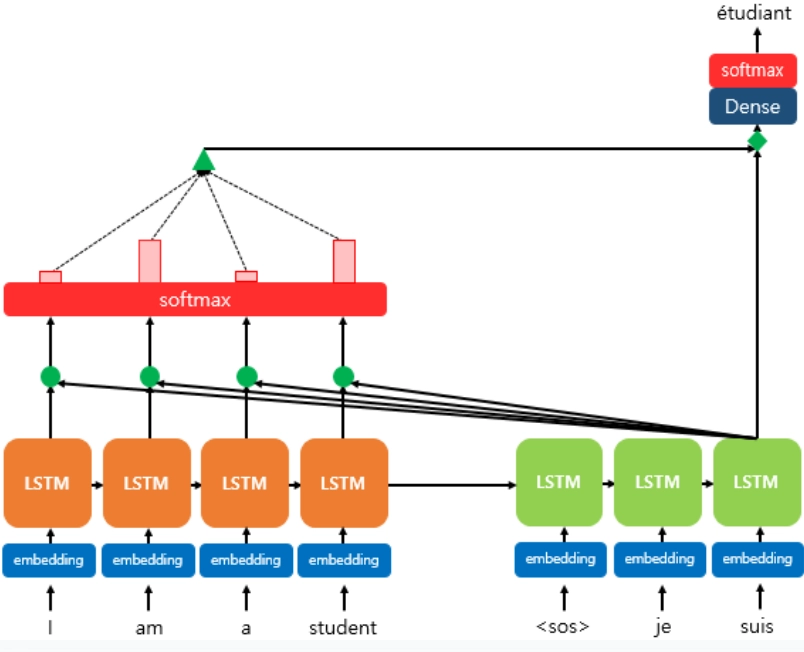  

- 중요한 정보에 더 집중하는 매커니즘 : 현재 시점에서 가장 중요한 부분에 더 높은 가중치를 부여하여 활용
- 출력 시점마다 새로운 컨텍스트 벡터를 동적 계산 -> *병렬화*
- 과정
    1. 입력을 벡터 형태로 변환
    2. 단어별 중요도 계산
    3. 중요도에 따른 입력 정보 조합
- 장점
    1. 시간 경과에 대한 유연성
        - RNN의 장기 의존성 문제 해결
        - 모든 단어에서 다른 모든 단어로 직접 연결 가능 = 아무리 떨어져있어도 정보 손실 없이 명확하게 파악 가능
    2. 공간에 대한 유연성
        - 이미지의 모든 픽셀이 다른 모든 픽셀과 직접 연결 -> 픽셀 간의 거리에 상관없이 한번에 전체 이미지의 전역적인 관계 학습 가능
    3. **병렬화**
        - self-attention에서 문장 내 모든 단어의 관계를 한번에, 독립적으로 계산 가능 = 병렬처리 가능

#### <span style="color: #000000;background-color: #ffc2e5">   **1-(2) Attention is All You Need**</span> 
- Transformer 구조를 처음 발표한 논문 (Self-Attention 방식)  
=> 반향 : Attention을 쓰던 딥러닝 모델들이 대부분 Self-Attention 방식을 채택하게 됨
- 내용
    1. 논문 배경 : RNN과 RNN 기반 모델들의 한계점  
        -> 인코더부터 디코더까지 오직 Attention만을 사용하는 모델을 만들면 어떨까?
    2. Transformer의 등장
    3. 논문에서 가장 중요한 발견
        - 성공적인 모델링에 Recurrence 및 Convolution이 필수가 아님을 증명
        - 모든 단어들을 동시게 계산할 수 있는 병렬화가 가증해짐
    4. 파급효과
        - LLM의 탄생
        - NLP 평정 : 거의 모든 자연어 처리 분야에서 트랜스포머 기반 모델들이 표준으로 자리잡게 됨
        - 타 분야로의 확장 : 컴퓨터 비전, 음성처리, 신약 개발 등 모든 영역으로 확장

##### <span style="color: #27baff">   **[Transformer란?]** <span> 
<U>**RNN의 순차적인 계산 방식을 완전히 버리고, 오직 어텐션으로만 문장의 의미와 구조를 파악하는 모델**</U>

- 핵심 기술
    1. Self-Attention : 문장 안에서 어떤 단어가 다른 단어들과 얼마나 중요한 관계를 맺고 있는지 한 번에 파악하는 기술
    2. Multi-Head Attention : 셀프 어텐션을 여러 개의 머리로 동시에, 서로 다른 관점에서 실행
    3. Positional Encoding : 단어의 위치 정보를 벡터에 추가하여 각 단어가 문장의 몇 번째 위치에 존재하는지 확인


### <span style="color: #000000;background-color: #ffdba4">**2. Self-Attention**</span>

#### <span style="color: #000000;background-color: #ffc2e5">   **2-(1) Query, Key, Value**</span> 
<U>**모델이 수많은 정보 안에서 가장 관련 있는 정보를 효과적으로 찾아내기 위해 3가지 역할로 분할**</U>

- Q : Query
    - 질문 또는 요청
    - 지금 당장 내가 알고 싶거나, 초점을 맞추고 있는 대상
- K : Key
    - 검색 대상이 되는 모든 정보들이 달고 있는 이름표 또는 색인
    - 쿼리는 이 키들과 자신을 비교하며 얼마나 관련 있는지 확인
- V : Value
    - 키와 한 쌍으로 묶여 있는 실제 내용물
    - 쿼리와 키의 관련도 계산이 끝나고, 가장 관련성이 높다고 판단된 키가 선택되면, 모델은 그 키에 해당하는 밸류를 가져와 사용

#### <span style="color: #000000;background-color: #ffc2e5">   **2-(2) 기존 Cross-Attention vs. Self-Attention**</span> 


| 구분 | 기존 어텐션 (Cross-Attention) | 셀프 어텐션 (Self-Attention) |
| --- | --- | --- |
| 핵심 아이디어 | 번역할 문장을 슬쩍슬쩍 보면서 단어를 생성 | 문장 자체를 뜯어보며 내부 관계를 파악 |
| 작동 방식 | 하나의 시퀀스가 완전히 다른 시퀀스를 참고하여 정보를 만들어내는 메커니즘 | 한 문장 내 모든 단어끼리 서로의 관계를 계산 |
| 참조 대상 | 서로 다른 시퀀스 (인코더 ↔ 디코더) | 동일한 시퀀스 (문장 내부 ↔ 문장 내부) |
| 주요 목적 | 인코더-디코더 연결, 정보 병목 현상 해소 | 시퀀스 내부의 문맥 및 의존 관계 파악 |
| 기반 아키텍처 | RNN (LSTM, GRU) | 트랜스포머 (Attention Only) |
| 병렬 처리 | 불가능 (순차적)  | 가능  |

##### <span style="color: #27baff">   **[기존 Attention]** <span> 
- 하나의 시퀀스가 완전히 다른 시퀀스를 참고하여 정보를 만들어내는 매커니즘 -> Decoder가 Encoder를 참고하는 과정
- 핵심 과정
    1. 쿼리 만들기 : 디코더는 지금까지 생성된 단어들을 보고 현재 상태를 하나의 벡터(쿼리)로 요약
    2. Key, Value 불러오기 : 인코더는 입력 문장을 처리해 각 단어에 대한 벡터 소유
    3. 유사도 계산 : 디코더의 쿼리가 인코더의 각 키와 유사도 계산
    4. Weighted Sum : 인코더의 Value들을 그 가중치로 섞음
    5. 디코더가 다음 단어 예측

##### <span style="color: #27baff">   **[Self-Attention]** <span>
- 문장 자체를 뜯어보며 내부의 관계 파악
    - 쿼리와 key-value 쌍이 같은 시퀀스에서 출력
    - 문장 스스로가 문맥을 이해하는 과정
- 핵심 과정
    1. 단어의 프로필 만들기(벡터 임베딩)
    2. 단어 간 관계 점수 계산(내장 및 정렬 점수)
    3. 중요도 배분(소프트맥스 & 어텐션 가중치)
    4. 새로운 벡터 생성

#### <span style="color: #000000;background-color: #ffc2e5">   **2-(3) Scaled Dot-Product Attention**</span> 
##### <span style="color: #27baff">   **[Dot-Product Attention]** <span> 
- Attention Score를 계산하는 가장 기본적인 방법 중 하나
- 뭐리와 키벡터를 내적하여 유사도 계산
- 기본 과정
    1. 쿼리 벡터와 모든 키 벡터를 각각 내적하여 유사도 계산 진행
    2. 계산된 값에 소프트맥스 함수를 적용하여 총합이 1인 Attention Weight 산출
    3. 이 가중치를 밸류 벡터에 곱하여 최종 결과값 계산
- 문제점 : Attention Score의 극단화
    - 벡터 차원이 커질수록 내적값이 지나치게 커지거나 작아질 수 있음
    - 이런 극단 값이 softmax에 입력되면 특정 단어에 확률이 과독하게 집중되고, Vanishing Gradient 문제 발생 가능

##### <span style="color: #27baff">   **[Scaled Dot-Product Attention]** <span> 
- 기존의 Dot-Product Attention의 문제를 해결하고자, "Attention is All You Need"의 저자들이 제안한 현재 트랜스포머 방식의 표준  
=> Transformer의 어텐션 계산 공식 자체
- 기존 문제 해결 방법
    - Dot-Product Attention 과정에서 내적을 진행한 후, 값의 크기를 맞추는 스케일링 과정 추가
- 과정
    1. 쿼리 벡터와 모든 키 벡터를 각각 내적하여 유사도 계산 진행
    2. **<U>계산된 값을 $\sqrt{d_K}$로 나누어 스케일링 진행</U>**
    3. 스케일링된 값에 softmax 함수를 적용하여 총합이 1인 Attention Weight 산출
    4. 이 가중치를 밸류 벡터에 곱하여 최종 결과값 계싼
- 한번의 나눗셈 => 계산된 내적 값이 과도하게 증가하는 것 방지=> 안정적인 분포 형성 => softmax 함수가 안정적으로 학습을 진행할 수 있도록 함
- Scaled Dot-Product Attention 계산의 결과로 얻어지는 벡터
    - Cross-Attention : 현재 생성 중인 단어가 입력 문장에서 어떤 단어들에 집중해야 하는지를 반영한 Context Vector
    - Self-Attention : 문장 내 다른 단어들과의 관계를 반영한 문맥적 표현


### <span style="color: #000000;background-color: #ffdba4">**3. Multi-Head Attention**</span>

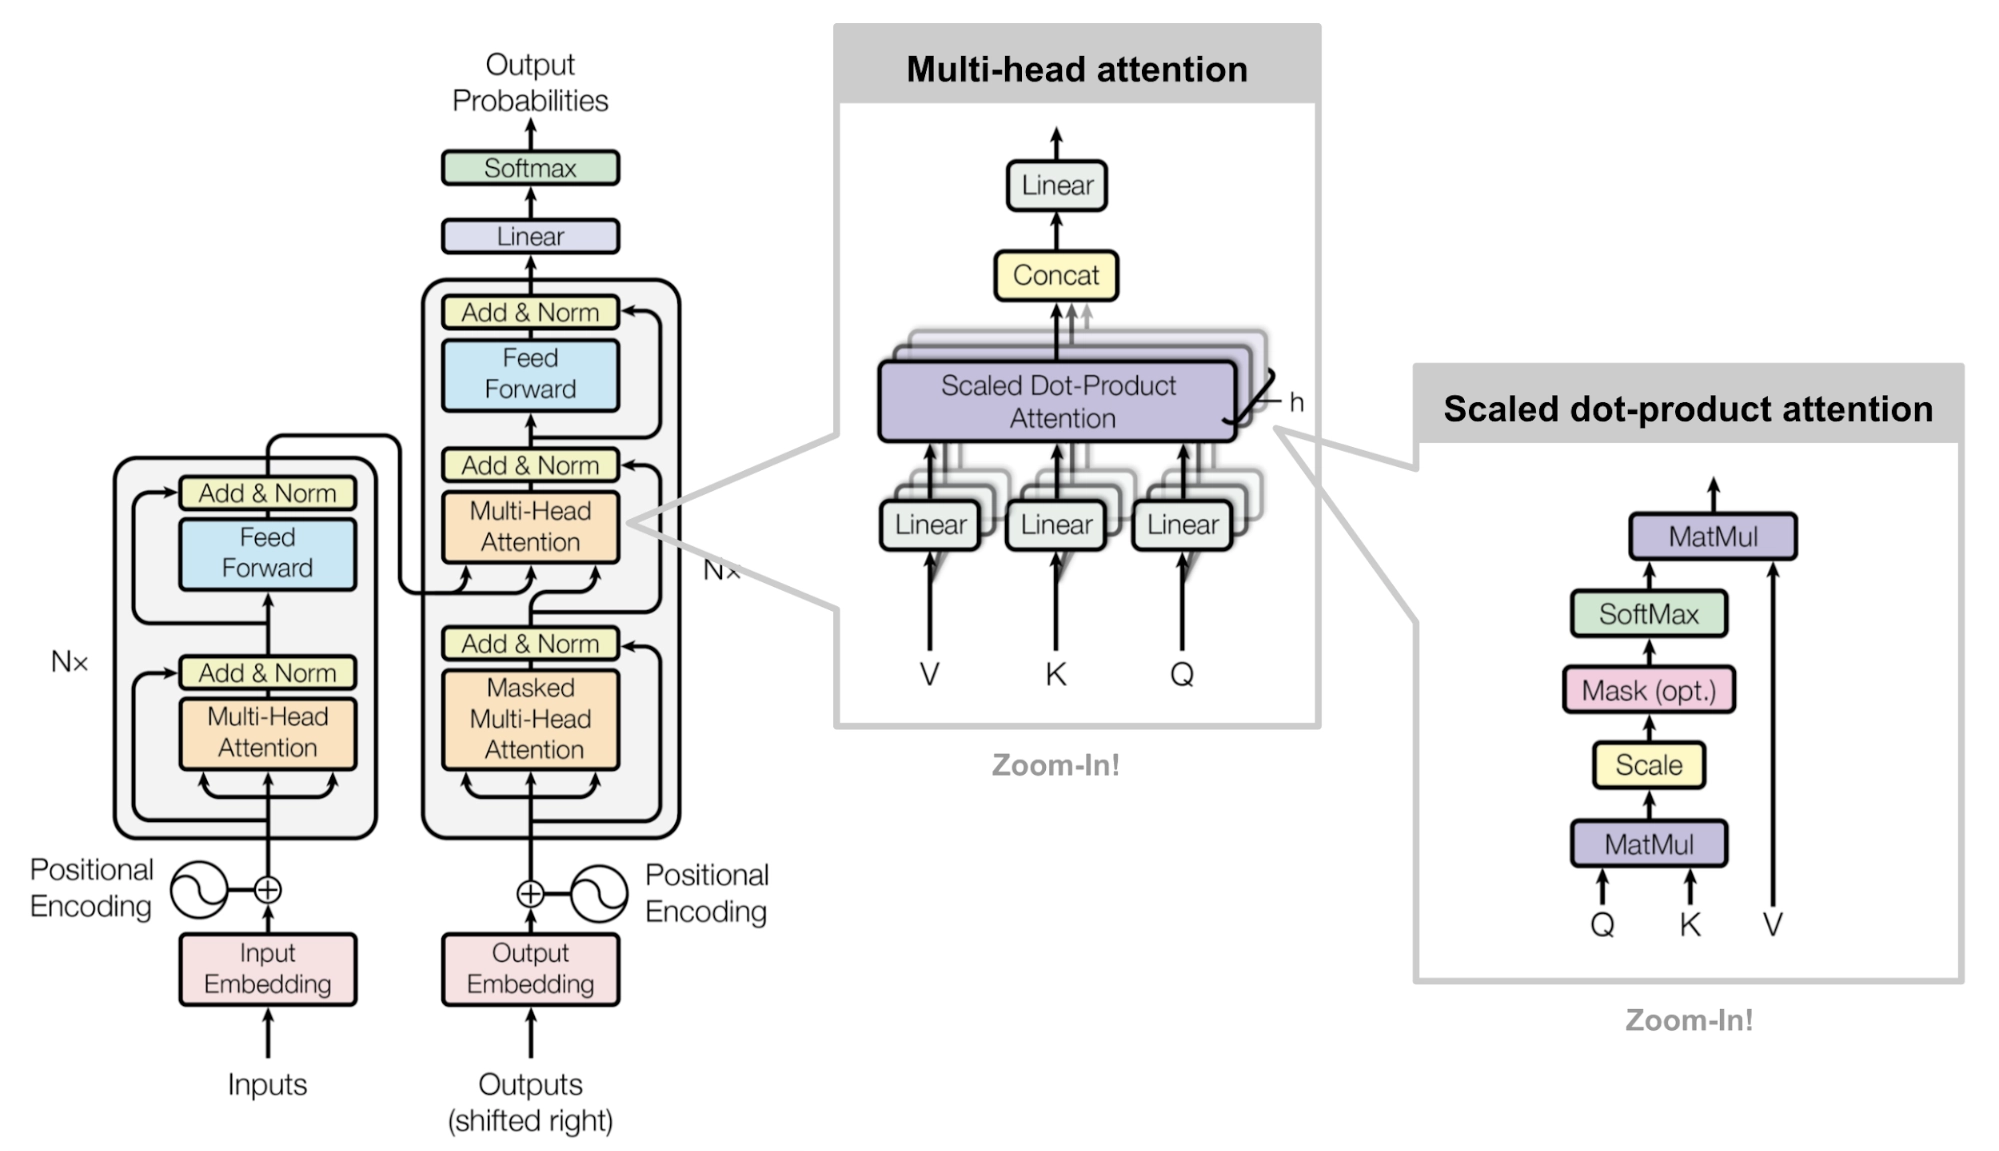

- Encoder에서는 Multi-Head Attention이 한 번 사용
- Decoder에서는 Multi-Head Attentnion이 두 번 사용
    - Masked Multi-Head Attention : 아직 생성되지 않은 미래 단어를 보지 못하도록 가리고, 현재까지 생성된 단어들만 참고
    - Encoder-Decoder Attention : Decoder가 출력을 생성할 때, 인코더가 이해한 입력 문장 정보를 참고
- Multi-Head Attention : 트랜스포머가 토큰들 사이의 관계를 파악하고, 문맥 정보를 반영하여 더 정확한 출력을 만들 수 있도록 도와주는 핵심 구조

#### <span style="color: #000000;background-color: #ffc2e5">   **3-(1) Why Multi-Head Attention?**</span> 
##### <span style="color: #27baff">   **[Single-Head Attention]** <span> 
- 문장 내 단어들 간의 관계를 파악하기 위해 하나의 가중치 행렬($W^Q,W^K,W^V$)만을 학습하고 번역에 사용
- 작동 방식
    - 512차원의 입력 벡터 -> 이 벡터를 위한 어텐션 가중치 분포 계산 -> 가중합하여 새로운 512차원의 벡터 출력
- 한계
    - 하나의 어텐션 분포 안에서 각 단어 간 문법적인 관계, 의미적인 관꼐, 위치 관계 등 모든 종류의 정보를 한 번에 담아 가중 평균을 구해버리기 때문에, 결국 각 단어 간의 중요한 관계를 놓쳐버릴 수 있음

##### <span style="color: #27baff">   **[Multi-Head Attention]** <span> 
- 한 단어와 다른 단어 간의 관계를 여러 차원으로 나누어 병렬로 학습
- *Attention is All you need* 논문에서는 512차원의 입력 벡터를 64차원씩 8개의 벡터로 나누고, Attention 스코어를 병렬로 여러번 계산

#### <span style="color: #000000;background-color: #ffc2e5">   **3-(2) Multi-Head Attention 작동 방식**</span> 
*예시 : 'I love you'라는 문장에서 love라는 단어의 벡터가 Multi-Head Attention Layer를 통과하는 과정*


##### <span style="color: #27baff">   **[(1) 분할 (Projection)- 8명의 헤드에 단어 벡터 할당]** <span> 
- 입력 : love vector(하나의 512차원 벡터)
    - 이 입력 벡터에 8세트의 서로 다른 가중치 행렬 곱함  
    -> 512차원의 큰 벡터가 서로 다른 관점을 담은 8개의 독립적인 64차원짜리 작은 벡터(Q,K,V 세트)들로 분할됨

##### <span style="color: #27baff">   **[(2)병렬 어텐션 계산-각 헤드들이 각자 분석 수행]** <span> 
- 8개의 헤드는 서로에게 간섭하지 않고 병렬로 Scaled Dot-Product Attention 계산
- 하나의 헤드에서..
    1. 점수계산(Score) : love의 쿼리 벡터를 문장 내 모든 단어의 key 벡터와 내적하여 관련성 점수 계산(이때 K 벡터는 transpose)
    2. 크기 조절(Scale) : 계산된 점수들을 각 헤드 차원의 제곱근(8)로 나누어줌
    3. 가중치 변환(Softmax) : 조절된 점수들에 소프트 맥스 함수 적용 -> 총합이 1인 Attention Weigth를 만듦(헤드의 관점에서 love가 다른 단어들에 얼마나 집중해야 하는지를 나타냄)
    4. 가중합 : 이 가중치를 문장 내 모든 단어의 Value 벡터에 곱한 뒤 모두 더함   

=> 이 과정의 결과로 헤드 하나에서 문맥을 이해한 64차원 결과 벡터가 나옴 -> 8개의 헤드에서 동시에 일어남

##### <span style="color: #27baff">   **[(3) 결합 및 최종 투영]** <span> 
1. 결합 (concatenate)
    - 8개의 64차원 결과 벡터들을 순서대로 이어 붙여 하나의 거대한 512차원 벡터 생성
2. 최종 투영(Final Projection)
    - 이 512차원 벡터는 아직 각 헤드의 분석 결과가 단순히 나열된 상태
    - 이 정보들을 잘 융합하고 최종적으로 정리하기 위해, 또 다른 가중치 행렬을 곱해줌
    - final_output=concat_output*W^O

=> 이 final_output이 바로 love라는 단어에 대한 Multi-Head Attention 레이어의 최종 출력 벡터

### <span style="color: #000000;background-color: #ffdba4">**4. Transformer 전체 아키텍처**</span>

#### <span style="color: #000000;background-color: #ffc2e5">   **4-(1) 트랜스포머의 전처리 단계**</span> 
##### <span style="color: #27baff">   **[토큰화]** <span>
- 입력 텍스트를 모델이 처리할 수 있는 단위(토큰)으로 나누는 첫번째 단계
- 토큰화 방법
    - 대부분의 경우 각 토큰은 하나의 **단어**에 해당
    - 문장 부호 역시 별도의 토큰
    - 일부 단어는 하나 이상의 토큰으로 나뉠 수 있음(doesn;t=>does,n't)

##### <span style="color: #27baff">   **[임베딩]** <span>
- 토큰화된 각 단위는 임베딩 단계에서 숫자의 벡터로 변환
- 임베딩 구조 : 많은 숫자로 이루어진 긴 벡터로 단어를 나타냄
    - 벡터의 길이 -> 벡터의 차원
- 원리 : 단어의 의미를 **공간적으로 표현**
    - 유사한 단어 -> 유사한 숫자

##### <span style="color: #27baff">   **[Positional Encoding]** <span>
- 단어들의 **순서 정보를 임베딩 벡터에 추가**하는 단계
- Transformer는 모든 단어를 병렬로 한번에 처리 = 단어의 순서를 알지 못함  
    => 같은 단어의 집합이라면 실제로는 의미가 다른데 똑같은 것으로 인식
- 동작 방식
    - 각 단어의 임베딩 좌표에 일관된 순서를 따르는 다른 숫자를 추가하여 순서 정보 기록
    - 이 과정을 통해 같은 단어라도 문장에서 차지하는 위치가 다르면 최종적으로 다른 좌표를 가지게 됨 (=순서학습)

#### <span style="color: #000000;background-color: #ffc2e5">   **4-(2) 트랜스포머의 Encoder와 Decoder**</span> 
##### <span style="color: #27baff">   **[Encoder]** <span>
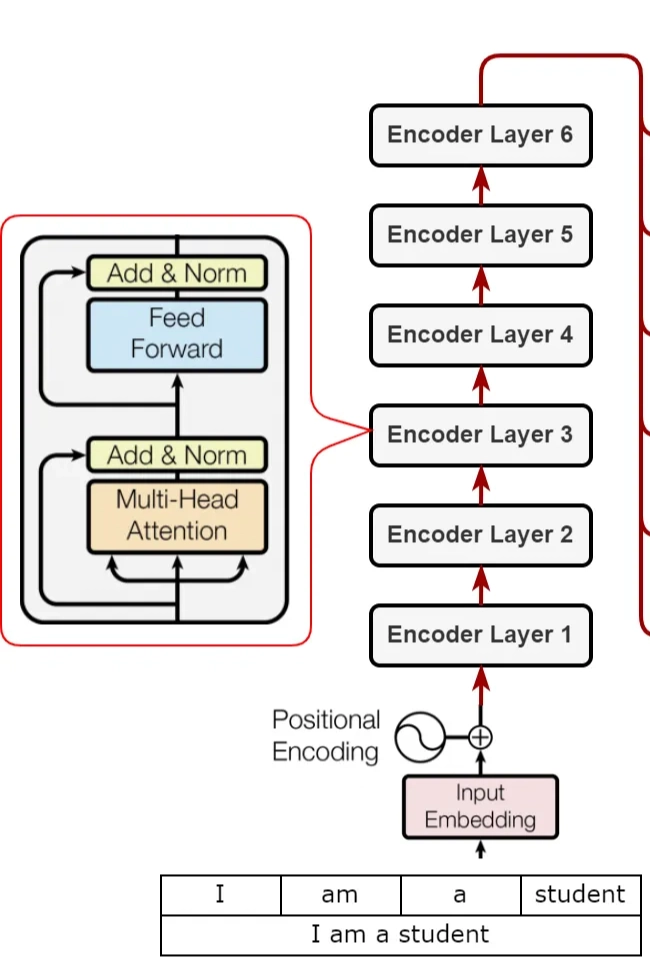

- 입력 문장을 이해하고 요악된 의미 벡터로 변환하는 역할
- 인코더 레이어의 구성
    - Multi-Head Attention
    - Feed-Forward : 입력 벡터의 차원을 확장하고 비선형 변환을 적용하여 새로운 표현을 생성하는 신경망 구조
    - Add&Norm
        - Residual connections(잔차 연결) 
            - 입력 값을 그대로 출력에 더해주는것
            - 층이 계속 쌓이게 되면 기울기 소실 및 폭주 현상 발생 가능 -> 지름길을 만들어서 출력에 입력값을 바로 전달
        - Layer Normalization(층 정규화)
            - 입력 벡터의 평균과 분산을 사용해서 정규화하는것 -> 학습을 안정화하고 모델이 빠르게 수렴하게 만들어줌

##### <span style="color: #27baff">   **[Decoder]** <span>
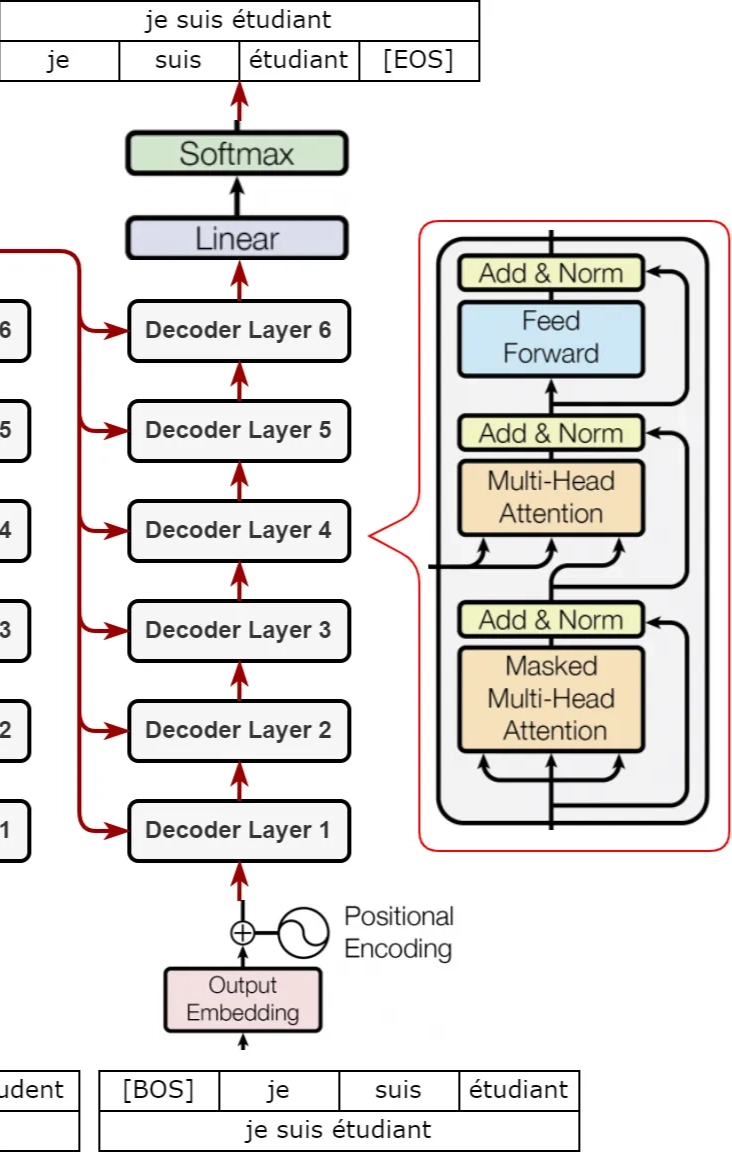
- Encoder가 분석한 입력 문장의 의미벡터를 받아서 출력 문장을 순차적으로 생성하는 역할 담당
- 디코더 레이어의 구성
    - Masked Multi-Head Attention
        - 미래 시점의 단어 정보를 참고하지 못하도록 마스크를 적용하는 어텐션 매커니즘
        - 모델이 이미 생성된 단어들만을 기반으로 다음 단어를 예측하도록 만듦 (미래에 있는 토큰의 어텐션 값을 0으로 만듦)
    - Encoder-Decoder Multi-Head Attention(Cross-Attention)
        - 디코더가 인코더의 출력을 참고하면서 현재 생성 중인 단어를 입력 문장의 의미와 연결하는 과정
            - Q : 디코더의 이전 서브레이어 출력
            - K,V : 인코더의 최종 출력    
        - 디코더가 입력 문장 중 어떤 부분에 주목해야 하는지를 학습
    - Feed-Forward Layer

#### <span style="color: #000000;background-color: #ffc2e5">   **4-(3) 전체 모델 및 데이터 흐름**</span> 
*I love you를 트랜스포머로 번역해보자*

##### <span style="color: #27baff">   **[1. 입력 준비 : 문장을 의미+위치 벡터로 바꾸기]** <span>
- 임베딩
    - 각 단어를 의미를 담은 숫자 벡터로 변환
    - I, love, you를 각각의 의미 벡터로 변환
- 포지셔널 인코딩
    - 순서 정보를 알 수 없으므로 각 단어의 위치에 해당하는 벡터를 의미 벡터에 더하기
    - I (1번째), love(2번째), you(3번째)에 각각 다른 위치 벡터를 더함  
   
 -> 의미와 위치 정보를 모두 갖춘 벡터가 인코더의 입력이 됨

##### <span style="color: #27baff">   **[2. 인코더 : 입력 문장의 문맥적 의미 깊이 이해하기]** <span>
- 셀프 어텐션
    - love가 문장 전체에서 어떤 의미를 갖는지 파악
    - love는 Query를 만들고 I,love,you의 K와 V를 참조해 연관성 점수 계산
- 관계 점수 계산
    - Q와 K의 내적으로 단어 간 관계 점수를 구하고 softmax로 확률 분포로 변환
    - love는 I와 0.2 자신과 0.7, you와 0.1 등의 가중치를 얻음
- 가중합
    - 계산된 가중치를 V 벡터에 곱하고 모두 더하여 새로운 벡터 생성
- 멀티-헤드
    - 여러 개의 어텐션 헤드를 통해 다양한 관점에서 문맥 파악  

-> 인코더의 최종 출력은 입력 문장 'I love you'의 컨텍스트 벡터이며, 이 벡터들은 디코더에서 K,V로 활용됨

##### <span style="color: #27baff">   **[3. 디코더 : 번역 문장을 한 단어씩 생성하기]** <span>
- 각 스텝에서 Masked Self-Attention 과 Encoder-Decoder Attention을 거쳐 출력 생성
- Step1
    - 입력 : <start>
    - 핵심 과정
        - Masked Self-Attention: <start> 자신만을 참고 (미래 단어 참조 불가)
        - Encoder–Decoder Attention: <start>에서 생성된 Q가 인코더 출력에 “첫 단어로 뭐가 중요하지?” 질문 → ‘I’에 가장 높은 어텐션 부여
    - 출력 : "나는"
- Step 2
    - 입력 : <start>, "나는"
    - 핵심 과정
        - Masked Self-Attention: “나는”이 이전 토큰<start>만 참고해 문맥 형성
        - Encoder–Decoder Attention: 새로운 Q가 인코더 출력에 “다음 단어로 무엇이 중요하지?” 질문 → ‘you’에 높은 점수
    - 출력 : "당신을"
- Step 3
    - 입력 : <start>, "나는", "당신을"
    - 핵심 과정 : 반복
    - 출력 : "사랑해"
- 종료
    - 입력 : <end>토큰 생성
    - 핵심 과정 : 디코딩 종료


=> "나는 당신을 사랑해" 출력
